![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

**Scharakteryzuj i porównaj liczbę kalorii dostarczaną przez tłuszcze, węglowodany, białko i błonnik dla grupy wybranych produktów firmy Starbucks. Wykonaj wykresy skrzynkowe oraz estymację jądrową rozkładów prawdopodobieństwa.
Oblicz prawdopodobieństwo otrzymania potrawy zawierającej pomiędzy 200 a 300 kcal.**

In [7]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
df = pd.read_csv("starbucks_menu_elements.csv",sep=";") 
df # display the data frame

,Food,Calories,Fat [g],Carb [g],Fiber [g],Protein [g]
0,Chonga Bagel,300,5.0,50,3,12
1,Almond Croissant,410,22.0,45,3,10
2,Apple Fritter,460,23.0,56,2,7
3,Banana Nut Bread,420,22.0,52,2,6
4,Blueberry Muffin with Yogurt and Honey,380,16.0,53,1,6
5,Butter Croissant,240,12.0,28,1,5
6,Butterfly Cookie,350,22.0,38,0,2
7,Cheese Danish,320,16.0,36,1,8
8,Chewy Chocolate Cookie,170,5.0,30,2,2
9,Chocolate Chip Cookie,310,15.0,42,2,4


#### Porównanie wkładu kalorycznego pochodzącego od różnych makroskładników

In [9]:
df.describe()

,Calories,Fat [g],Carb [g],Fiber [g],Protein [g]
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,359.047619,15.666667,47.904762,2.285714,7.809524
std,110.222718,7.928325,14.296520,2.077086,5.114871
min,120.000000,1.000000,18.000000,0.000000,2.000000
25%,300.000000,12.000000,38.000000,1.000000,6.000000
50%,380.000000,16.000000,50.000000,2.000000,7.000000
75%,420.000000,22.000000,56.000000,2.000000,9.000000
max,600.000000,25.000000,80.000000,10.000000,23.000000


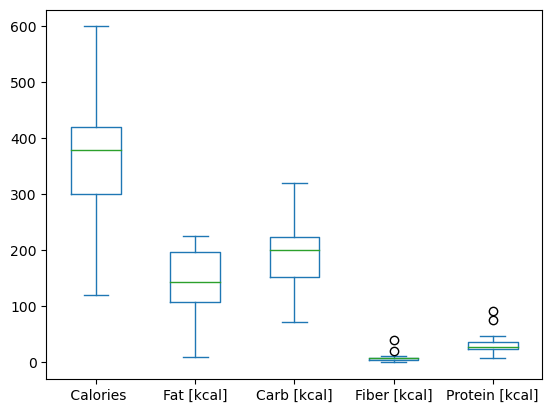

In [10]:
df["Fat [kcal]"] = df[df.columns[2]]*9
df["Carb [kcal]"] = df[df.columns[3]]*4
df["Fiber [kcal]"] = df[df.columns[4]]*4
df["Protein [kcal]"] = df[df.columns[5]]*4

df[df.columns[np.concatenate([[1],list(range(6,10))])]].plot.box() # wykres skrzynkowy udziału kalorycznego
pass

#### Utworzenie estymatora jądrowego dla zmiennej " Calories"

In [11]:
kcalX = df[df.columns[1]].values
kde_estimator = st.gaussian_kde(kcalX)

#### Prawdpodobieństwo otrzymania potrawy o kaloryczności między 200 a 300 kcal

In [12]:
a = 200
b = 300
p = kde_estimator.integrate_box_1d(a,b) # całkowanie estymatora jądrowego w przedziale [a,b]=[200,300]
p # prawdopodobieństwo otrzymania potrawy między 200 a 300 kalorii

0.19519049540576736

#### Wykres gęstości prawdopodbieństwa dla zmiennej " Calories"

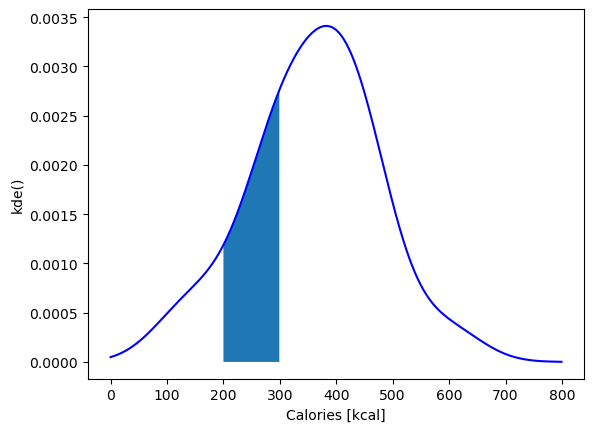

In [13]:
t = np.arange(0,800,1) # zakres kalorii dla rysunku funkcji kde
tf = np.arange(a,b,1) # zakres kalorii dla rysunku wypełnienia

plt.fill_between(tf,0,kde_estimator(tf))
plt.plot(t,kde_estimator(t),"blue")
plt.xlabel("Calories [kcal]")
plt.ylabel("kde()")
pass

Text(0.5, 1.0, 'Gęstość rozkadu prawdopodbieństwa liczby kalorii')

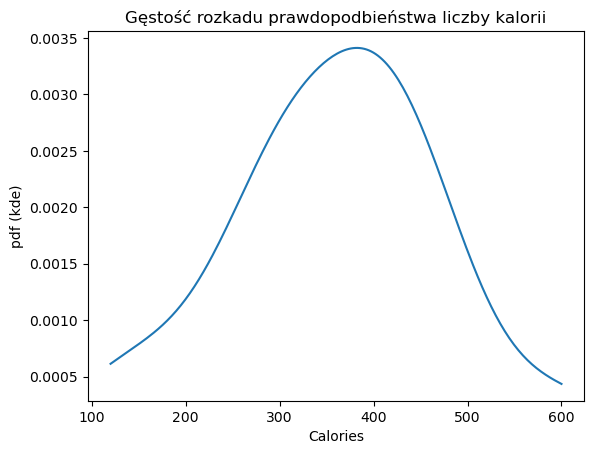

In [17]:
x = np.linspace(df[" Calories"].min(),df[" Calories"].max(),200)

plt.plot(x,kde_estimator.pdf(x))
plt.xlabel("Calories")
plt.ylabel("pdf (kde)")
# pdf uzskana za pomocą jądrowego estymatoa gęstości rozkądu prawdopodobieństwa (kde)
plt.title("Gęstość rozkadu prawdopodbieństwa liczby kalorii")